In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import save_image

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data"
generated_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED"

os.makedirs(generated_path, exist_ok=True)

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [ ]:

from torch.utils.data import Dataset
from torch.utils.data import Dataset


class FaceDataset(Dataset):

    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform

        # store sorted file list
        self.files = sorted([
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ])

    def __len__(self):
        return len(self.files)   # ✅ FIXED (was image_files)

    def __getitem__(self, idx):
        fname = self.files[idx]   # ✅ correct indentation
        path = os.path.join(self.folder_path, fname)

        img = Image.open(path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


In [ ]:
dataset = FaceDataset(dataset_path, transform=transform)

In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle= False,
    num_workers=0
)

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

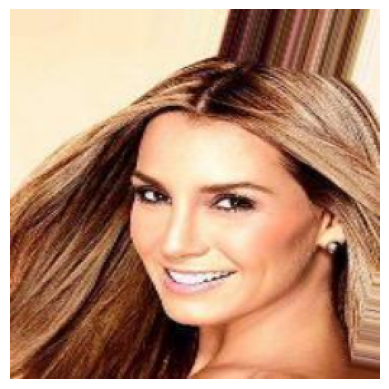

In [ ]:
import matplotlib.pyplot as plt

images = next(iter(dataloader))

plt.imshow(images[0].permute(1,2,0)*0.5 + 0.5)
plt.axis("off")

In [ ]:
import torch
import torch.nn as nn

class Generator(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),      # 128 → 64
            nn.ReLU(True),

            nn.Conv2d(64,128,4,2,1),    # 64 → 32
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.Conv2d(128,256,4,2,1),   # 32 → 16
            nn.BatchNorm2d(256),
            nn.ReLU(True)
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1),   # 16 → 32
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128,64,4,2,1),    # 32 → 64
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64,3,4,2,1),      # 64 → 128
            nn.Tanh()
        )

    def forward(self,x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [ ]:
class Discriminator(nn.Module):

    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(

            nn.Conv2d(3,64,4,2,1),   # 256 → 128
            nn.LeakyReLU(0.2),

            nn.Conv2d(64,128,4,2,1), # 128 → 64
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128,256,4,2,1), # 64 → 32
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(256*32*32,1),   # ← FIXED SIZE
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.model(x)

In [ ]:
G = Generator().to(device)
D = Discriminator().to(device)

In [ ]:
criterion = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0003, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=0.00005, betas=(0.5, 0.999))

epsilon = 0.075
epochs = 5

In [ ]:
from tqdm.auto import tqdm
from torchvision.utils import save_image
import os

lambda_perturb = 0.035

# =========================================================
# SAVE SETUP
# =========================================================
save_folder = generated_path
os.makedirs(save_folder, exist_ok=True)

# dataset.files must be sorted in FaceDataset
real_files = dataset.files

# keeps track of file sequence
global_img_idx = 0

for epoch in range(epochs):
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}")

    for real in pbar:
        real = real.to(device)
        batch = real.size(0)

        real_label = torch.ones(batch, 1).to(device)
        fake_label = torch.zeros(batch, 1).to(device)

        # -------------------
        # Train Discriminator
        # -------------------
        perturb = G(real)
        spoof = real + epsilon * perturb
        spoof = torch.clamp(spoof, -1, 1)

        D_real = D(real)
        D_fake = D(spoof.detach())

        loss_real = criterion(D_real, real_label)
        loss_fake = criterion(D_fake, fake_label)
        loss_D = loss_real + loss_fake

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # -------------------
        # Train Generator
        # -------------------
        perturb = G(real)
        spoof = real + epsilon * perturb
        spoof = torch.clamp(spoof, -1, 1)

        D_fake = D(spoof)
        adv_loss = criterion(D_fake, real_label)
        perturb_loss = torch.mean(torch.abs(perturb))

        loss_G = adv_loss + lambda_perturb * perturb_loss

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        pbar.set_postfix(D_loss=loss_D.item(), G_loss=loss_G.item())

        # -------------------
        # Save fake images in exact real-data sequence
        # -------------------
        with torch.no_grad():
            for i in range(spoof.size(0)):

                if global_img_idx >= len(real_files):
                    break

                real_name = real_files[global_img_idx]
                base_name = os.path.splitext(real_name)[0]

                save_path = os.path.join(save_folder, f"{base_name}_fake.png")
                save_image(spoof[i], save_path, normalize=True)

                global_img_idx += 1

    print(f"Epoch {epoch+1}/{epochs} | D Loss: {loss_D.item():.4f} | G Loss: {loss_G.item():.4f}")

Epoch 1/5:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 1/5 | D Loss: 1.5597 | G Loss: 1.3211


Epoch 2/5:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 2/5 | D Loss: 1.4755 | G Loss: 1.2634


Epoch 3/5:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 3/5 | D Loss: 1.4773 | G Loss: 1.3086


Epoch 4/5:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 4/5 | D Loss: 1.7103 | G Loss: 1.5516


Epoch 5/5:   0%|          | 0/1500 [00:00<?, ?it/s]

Epoch 5/5 | D Loss: 1.4027 | G Loss: 0.6763


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.fftpack import dct
from scipy.ndimage import gaussian_filter
from tqdm import tqdm

# =========================================================
# CONFIG
# =========================================================
real_folder = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data"                  # folder-level real
fake_folder = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED"         # folder-level fake

# MANUAL single-image paths
single_real_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data/000090.jpg"          # change this
single_fake_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED/000090_fake.png"  # change this

IMG_SIZE = 256

LOW_RATIO = 0.10
MID_RATIO = 0.30
HEATMAP_SIGMA = 6

# =========================================================
# HELPERS
# =========================================================
def load_img(path, size=256):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size))
    return np.array(img).astype(np.float32) / 255.0

def dct2(channel):
    return dct(dct(channel.T, norm="ortho").T, norm="ortho")

def compute_dct_band_energy(img, low_ratio=0.10, mid_ratio=0.30):
    energies = {"low": 0.0, "mid": 0.0, "high": 0.0}

    for c in range(3):
        coeff = dct2(img[:, :, c])
        coeff = np.abs(coeff)

        h, w = coeff.shape
        low_cut = max(1, int(h * low_ratio))
        mid_cut = max(low_cut + 1, int(h * mid_ratio))

        # LOW
        low = coeff[:low_cut, :low_cut].sum()

        # MID
        mid_mask = np.zeros_like(coeff, dtype=bool)
        mid_mask[:mid_cut, :mid_cut] = True
        mid_mask[:low_cut, :low_cut] = False
        mid = coeff[mid_mask].sum()

        # HIGH
        high_mask = np.ones_like(coeff, dtype=bool)
        high_mask[:mid_cut, :mid_cut] = False
        high = coeff[high_mask].sum()

        energies["low"] += low
        energies["mid"] += mid
        energies["high"] += high

    return energies

def get_sorted_image_files(folder):
    return sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

def process_folder(folder, low_ratio=0.10, mid_ratio=0.30):
    files = get_sorted_image_files(folder)

    total = {"low": 0.0, "mid": 0.0, "high": 0.0}
    count = 0

    for fname in tqdm(files, desc=f"Processing {folder}"):
        path = os.path.join(folder, fname)

        try:
            img = load_img(path, IMG_SIZE)
            energy = compute_dct_band_energy(img, low_ratio, mid_ratio)

            for k in total:
                total[k] += energy[k]
            count += 1

        except Exception as e:
            print(f"Skipping {fname}: {e}")

    if count == 0:
        raise ValueError(f"No valid images found in {folder}")

    avg = {k: total[k] / count for k in total}
    return avg

def dct_rgb(img):
    out = []
    for c in range(3):
        out.append(dct2(img[:, :, c]))
    return np.stack(out, axis=-1)

# =========================================================
# 1) FOLDER-LEVEL REPORT
# =========================================================
real_avg = process_folder(real_folder, LOW_RATIO, MID_RATIO)
fake_avg = process_folder(fake_folder, LOW_RATIO, MID_RATIO)

diff_avg = {k: fake_avg[k] - real_avg[k] for k in real_avg}

print("\n" + "="*60)
print("FOLDER-LEVEL FREQUENCY REPORT")
print("="*60)

print("\nReal folder average:")
for k, v in real_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake folder average:")
for k, v in fake_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in diff_avg.items():
    print(f"{k.upper():>5}: {v:.4f}")
# =========================================================
# 2) PAIRWISE COMPARISON REPORT
# =========================================================

real_files = get_sorted_image_files(real_folder)
fake_files = get_sorted_image_files(fake_folder)

assert len(real_files) == len(fake_files), "Mismatch in real and fake image counts!"

mid_high_count = 0
high_only_count = 0

total_pairs = len(real_files)

for r_name, f_name in tqdm(zip(real_files, fake_files), total=total_pairs, desc="Pairwise Comparison"):

    real_path = os.path.join(real_folder, r_name)
    fake_path = os.path.join(fake_folder, f_name)

    try:
        real_img = load_img(real_path, IMG_SIZE)
        fake_img = load_img(fake_path, IMG_SIZE)

        real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
        fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)

        # CONDITION 1: MID + HIGH both higher
        if (fake_energy["mid"] > real_energy["mid"]) and (fake_energy["high"] > real_energy["high"]):
            mid_high_count += 1

        # CONDITION 2: ONLY HIGH higher
        if fake_energy["high"] > real_energy["high"]:
            high_only_count += 1

    except Exception as e:
        print(f"Skipping pair {r_name}, {f_name}: {e}")

print("\n" + "="*60)
print("PAIRWISE FREQUENCY COMPARISON")
print("="*60)

print(f"Total Pairs: {total_pairs}")
print(f"Fake > Real in MID + HIGH: {mid_high_count}")
print(f"Fake > Real in HIGH only: {high_only_count}")

print("\nPercentages:")
print(f"MID + HIGH: {(mid_high_count / total_pairs) * 100:.2f}%")
print(f"HIGH only : {(high_only_count / total_pairs) * 100:.2f}%")

Processing /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data: 100%|██████████| 12000/12000 [04:45<00:00, 41.97it/s] 
Processing /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED: 100%|██████████| 12000/12000 [05:29<00:00, 36.47it/s] 



FOLDER-LEVEL FREQUENCY REPORT

Real folder average:
  LOW: 2427.1672
  MID: 2059.9121
 HIGH: 2453.4546

Fake folder average:
  LOW: 2426.0112
  MID: 1973.7399
 HIGH: 3109.7803

Difference (Fake - Real):
  LOW: -1.1560
  MID: -86.1722
 HIGH: 656.3257


Pairwise Comparison: 100%|██████████| 12000/12000 [05:11<00:00, 38.52it/s]


PAIRWISE FREQUENCY COMPARISON
Total Pairs: 12000
Fake > Real in MID + HIGH: 884
Fake > Real in HIGH only: 11000

Percentages:
MID + HIGH: 7.37%
HIGH only : 91.67%



SINGLE-IMAGE FREQUENCY REPORT

Real image energy:
  LOW: 2972.9700
  MID: 3157.5762
 HIGH: 6877.0205

Fake image energy:
  LOW: 2956.7502
  MID: 2973.8723
 HIGH: 6023.0098

Difference (Fake - Real):
  LOW: -16.2197
  MID: -183.7039
 HIGH: -854.0107


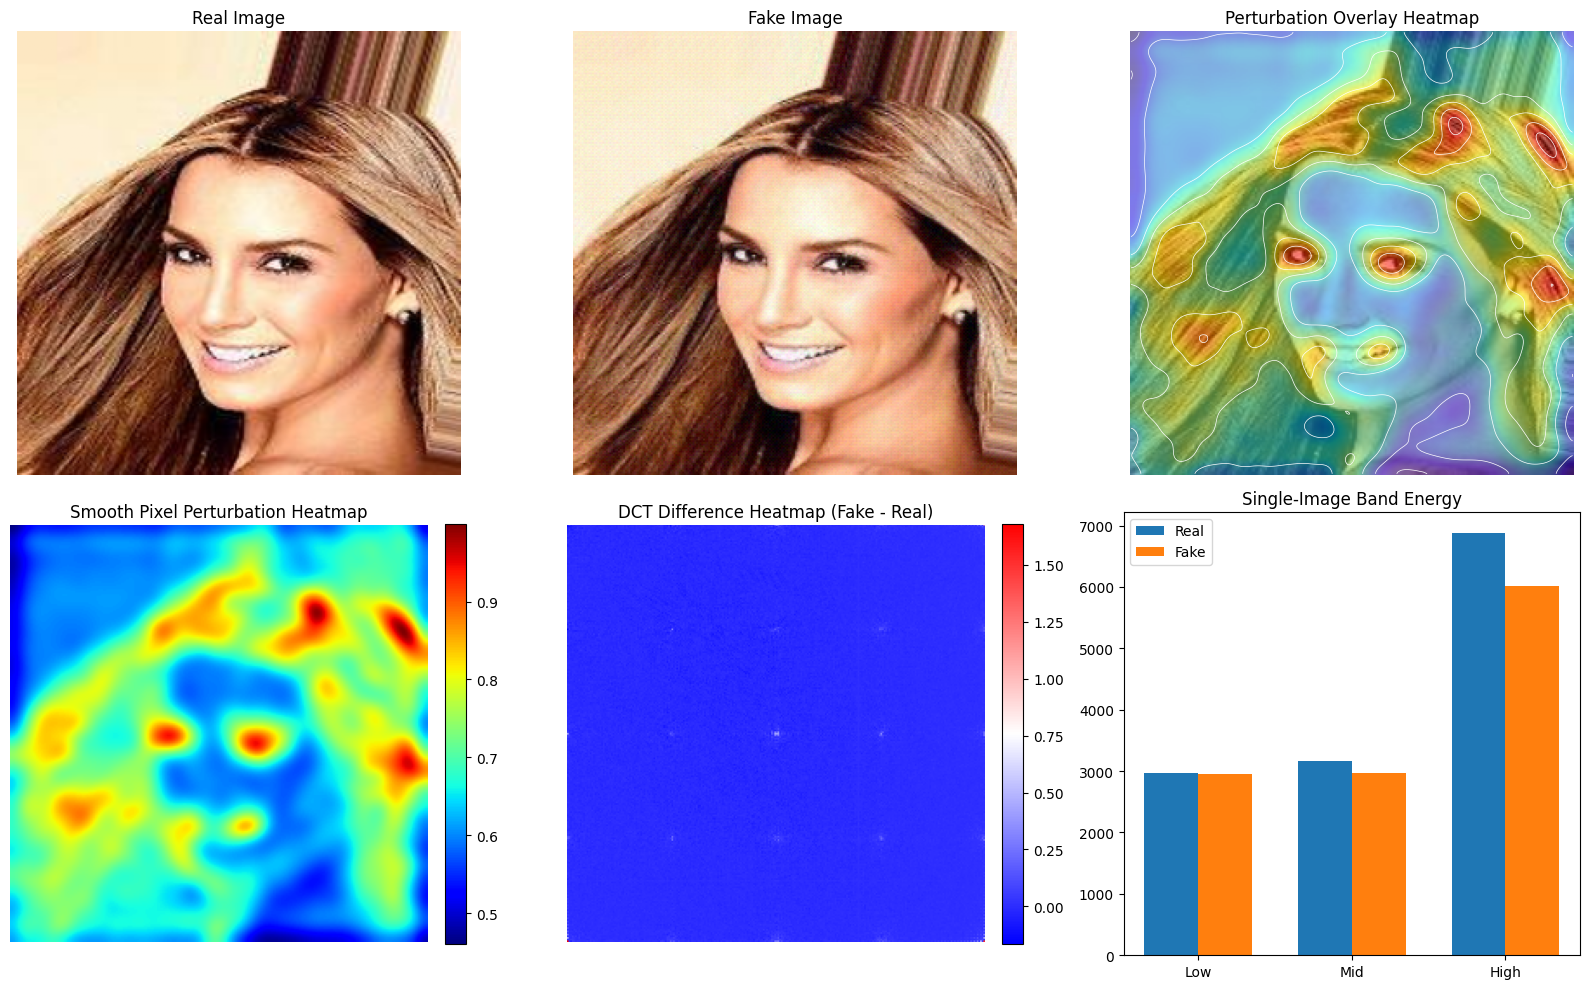


Single real path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data/000001.jpg
Single fake path : /content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED/000001_fake.png


In [ ]:
# MANUAL single-image paths
single_real_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/real_data/000001.jpg"          # change this
single_fake_path = "/content/drive/MyDrive/Colab Notebooks/thesis dataset/train/fake_data/DP_GAN_SPOOFED/000001_fake.png"  # change this

# =========================================================
# 2) SINGLE-IMAGE REPORT (MANUAL PATH INPUT)
# =========================================================
real_img = load_img(single_real_path, IMG_SIZE)
fake_img = load_img(single_fake_path, IMG_SIZE)

real_energy = compute_dct_band_energy(real_img, LOW_RATIO, MID_RATIO)
fake_energy = compute_dct_band_energy(fake_img, LOW_RATIO, MID_RATIO)
single_diff = {k: fake_energy[k] - real_energy[k] for k in real_energy}

print("\n" + "="*60)
print("SINGLE-IMAGE FREQUENCY REPORT")
print("="*60)

print("\nReal image energy:")
for k, v in real_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nFake image energy:")
for k, v in fake_energy.items():
    print(f"{k.upper():>5}: {v:.4f}")

print("\nDifference (Fake - Real):")
for k, v in single_diff.items():
    print(f"{k.upper():>5}: {v:.4f}")

# =========================================================
# 3) HEATMAPS FOR THE SAME SINGLE IMAGE
# =========================================================
delta = np.abs(fake_img - real_img)
delta_gray = delta.mean(axis=2)
smooth_map = gaussian_filter(delta_gray, sigma=HEATMAP_SIGMA)
smooth_map = smooth_map / (smooth_map.max() + 1e-8)

real_dct = dct_rgb(real_img)
fake_dct = dct_rgb(fake_img)

real_dct_mag = np.abs(real_dct).mean(axis=2)
fake_dct_mag = np.abs(fake_dct).mean(axis=2)
dct_diff = fake_dct_mag - real_dct_mag

# =========================================================
# 4) PLOTS
# =========================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

axes[0, 0].imshow(real_img)
axes[0, 0].set_title("Real Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(fake_img)
axes[0, 1].set_title("Fake Image")
axes[0, 1].axis("off")

axes[0, 2].imshow(real_img)
axes[0, 2].imshow(smooth_map, cmap="jet", alpha=0.5)
axes[0, 2].contour(smooth_map, colors="white", linewidths=0.5)
axes[0, 2].set_title("Perturbation Overlay Heatmap")
axes[0, 2].axis("off")

im1 = axes[1, 0].imshow(smooth_map, cmap="jet")
axes[1, 0].set_title("Smooth Pixel Perturbation Heatmap")
axes[1, 0].axis("off")
plt.colorbar(im1, ax=axes[1, 0], fraction=0.046, pad=0.04)

im2 = axes[1, 1].imshow(dct_diff, cmap="bwr")
axes[1, 1].set_title("DCT Difference Heatmap (Fake - Real)")
axes[1, 1].axis("off")
plt.colorbar(im2, ax=axes[1, 1], fraction=0.046, pad=0.04)

bands = ["Low", "Mid", "High"]
real_vals = [real_energy["low"], real_energy["mid"], real_energy["high"]]
fake_vals = [fake_energy["low"], fake_energy["mid"], fake_energy["high"]]

x = np.arange(len(bands))
width = 0.35

axes[1, 2].bar(x - width/2, real_vals, width, label="Real")
axes[1, 2].bar(x + width/2, fake_vals, width, label="Fake")
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(bands)
axes[1, 2].set_title("Single-Image Band Energy")
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("\nSingle real path :", single_real_path)
print("Single fake path :", single_fake_path)

In [ ]:
# =========================================================
# 4) DATASET CONSTRUCTION (FIXED LOGIC)
# =========================================================

import shutil
import random

save_final_folder = "/content/drive/MyDrive/Colab Notebooks/DP_GAN_SPOOFED_FINAL"
os.makedirs(save_final_folder, exist_ok=True)

# Already computed lists from previous block:
# mid_high_files  -> use f_name
# all_low_files   -> use f_name
# high_only_files -> use f_name

mid_high = [f for _, f in mid_high_files]
all_low = [f for _, f in all_low_files]
high_only = [f for _, f in high_only_files]

TOTAL_TARGET = 6000

print("\nInitial counts:")
print(f"MID + HIGH: {len(mid_high)}")
print(f"ALL LOW   : {len(all_low)}")
print(f"HIGH ONLY : {len(high_only)}")

# =========================================================
# FIXED SELECTION
# =========================================================

selected_mid_high = mid_high
selected_all_low = all_low

remaining_needed = TOTAL_TARGET - (len(selected_mid_high) + len(selected_all_low))

if remaining_needed > len(high_only):
    raise ValueError("Not enough HIGH-ONLY samples to reach 6000!")

selected_high_only = random.sample(high_only, remaining_needed)

# Final dataset
final_selection = selected_mid_high + selected_all_low + selected_high_only

print("\nFinal selection:")
print(f"MID + HIGH: {len(selected_mid_high)}")
print(f"ALL LOW   : {len(selected_all_low)}")
print(f"HIGH ONLY : {len(selected_high_only)}")
print(f"TOTAL     : {len(final_selection)}")

# =========================================================
# COPY FILES
# =========================================================

print("\nSaving dataset...")

for fname in tqdm(final_selection, desc="Copying Files"):
    src = os.path.join(fake_folder, fname)
    dst = os.path.join(save_final_folder, fname)

    try:
        shutil.copy(src, dst)
    except Exception as e:
        print(f"Error copying {fname}: {e}")

print("\nDataset creation complete ✅")


Initial counts:
MID + HIGH: 884
ALL LOW   : 758
HIGH ONLY : 10116

Final selection:
MID + HIGH: 884
ALL LOW   : 758
HIGH ONLY : 4358
TOTAL     : 6000

Saving dataset...


Copying Files: 100%|██████████| 6000/6000 [01:42<00:00, 58.66it/s]


Dataset creation complete ✅


In [ ]:
import os

path = '/content/drive/MyDrive/Colab Notebooks/DP_GAN_SPOOFED_FINAL'
# List comprehension to count only files
file_count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
print(f"Total files: {file_count}")

Total files: 6000
